<a href="https://colab.research.google.com/github/franklinzhou-ncsu/new_repo_554/blob/main/ST_554_Homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Subject: ST 554 - Homework 6

Name: Franklin Zhou

Date: 3/7/2026

For this homework you will create a gitHub repo (or use the one from homework 5) and save a python notebook (`.ipynb` file) using Google Colab there. We’ll also create a `.py` file for part II. This should be saved in your repo as well. You’ll then submit a link to your gitHub repo. Be sure to:

- change the sharing settings on your notebook. This can be done by clicking on the ‘share’ icon in the top right. Please make sure to change the sharing settings so that anyone with the link can see the notebook.
- **include markdown text describing what you are doing, even when not explicitly asked for!**
- Add comments to your `.py` file explaining what you are doing.

The purpose of this homework is to get a little more practice with SQL and gain some practice with creating classes.

# Part I - More Practice Querying a Database (16 pts)

There is a database file on the assignment link called lahman_1871-2022.sqlite that is an sqlite database [downloaded from here](https://github.com/jknecht/baseball-archive-sqlite). This database has information on Major League Baseball.

1. Connect to the database and then look at all of the tables in the database (use `read_sql()` from `pandas` to have this returned as a data frame). (2 pts)


In [1]:
import sqlite3
import pandas as pd

# Connect to the SQLite database
con = sqlite3.connect('lahman_1871-2022.sqlite')

# Get all tables in the database
get_schema = '''
        SELECT *
        FROM sqlite_schema
        WHERE type = "table";
        '''
pd.read_sql(get_schema, con)

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


2. Using SQL, construct a table of hall of fame pitchers (any hall of famer that pitched) that gives the `playerID` and their total (sum) for `GS`, `G`, `W`, `L`, `IPOuts`, `CG`, `SHO`, and `SV` columns. The summing can be done in `pandas` or in the SQL call. (6 pts)

In [17]:
get_schema = '''
    SELECT
        p.playerID,
        SUM(p.GS) AS GS,
        SUM(p.G) AS G,
        SUM(p.W) AS W,
        SUM(p.L) AS L,
        SUM(p.IPOuts) AS IPOuts,
        SUM(p.CG) AS CG,
        SUM(p.SHO) AS SHO,
        SUM(p.SV) AS SV
    FROM Pitching p
    JOIN HallOfFame h
        ON p.playerID = h.playerID
    WHERE h.inducted = 'Y'
    GROUP BY p.playerID;
    '''
pitching_stats = pd.read_sql(get_schema, con)
pitching_stats

,playerID,GS,G,W,L,IPOuts,CG,SHO,SV
0,alexape01,599,696,373,208,15570,437,90,32
1,ansonca01,0,3,0,1,12,0,0,1
2,becklja01,1,1,0,1,12,0,0,0
3,bendech01,334,459,212,127,9051,255,40,34
4,blylebe01,685,692,287,250,14910,242,60,0
...,...,...,...,...,...,...,...,...,...
103,willivi01,471,513,249,205,11988,388,50,11
104,wrighge01,0,3,0,1,15,0,0,0
105,wrighha01,8,36,4,4,301,0,0,14
106,wynnea01,612,691,300,244,13692,290,49,15



3. For all of the hall of fame pitchers, use SQL to create a table of their batting statistics. Namely, the
`playerID` and their total (sum) for `AB`, `R`, `H`, `HR`, `RBI`, `BB`, and `SO`. The summing can be done in `pandas`
or in the SQL call. (4 pts)


In [18]:
# then left join with Batting to get batting statistics
get_schema = '''
    SELECT
        b.playerID,
        SUM(b.AB)  AS AB,
        SUM(b.R)   AS R,
        SUM(b.H)   AS H,
        SUM(b.HR)  AS HR,
        SUM(b.RBI) AS RBI,
        SUM(b.BB)  AS BB,
        SUM(b.SO)  AS SO
    FROM Batting b
    WHERE b.playerID IN (
        SELECT DISTINCT h.playerID
        FROM HallOfFame h
        JOIN Pitching p
            ON h.playerID = p.playerID
        WHERE h.inducted = 'Y'
    )
    GROUP BY b.playerID;
    '''
Batting_stats = pd.read_sql(get_schema, con)
Batting_stats

,playerID,AB,R,H,HR,RBI,BB,SO
0,alexape01,1810,154,378,11,163,77,276
1,ansonca01,10281,1999,3435,97,2075,984,330
2,becklja01,9551,1603,2938,87,1581,616,526
3,bendech01,1147,102,243,6,116,75,143
4,blylebe01,451,19,59,0,25,5,193
...,...,...,...,...,...,...,...,...
103,willivi01,1493,107,248,1,84,81,199
104,wrighge01,2873,665,866,11,326,68,119
105,wrighha01,813,183,224,4,113,37,14
106,wynnea01,1704,136,365,17,173,141,330


4. Using `pandas` join the previous two tables together by pitcher. (If you want, try to do all of this via
SQL! Not required though, feel free to use `pd.merge()` if you’d like) (4 pts)

In [19]:
# Using pd.merge()
hall_of_fame_pitchers_stats = pd.merge(pitching_stats, Batting_stats, on='playerID', how='inner')
hall_of_fame_pitchers_stats

,playerID,GS,G,W,L,IPOuts,CG,SHO,SV,AB,R,H,HR,RBI,BB,SO
0,alexape01,599,696,373,208,15570,437,90,32,1810,154,378,11,163,77,276
1,ansonca01,0,3,0,1,12,0,0,1,10281,1999,3435,97,2075,984,330
2,becklja01,1,1,0,1,12,0,0,0,9551,1603,2938,87,1581,616,526
3,bendech01,334,459,212,127,9051,255,40,34,1147,102,243,6,116,75,143
4,blylebe01,685,692,287,250,14910,242,60,0,451,19,59,0,25,5,193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,willivi01,471,513,249,205,11988,388,50,11,1493,107,248,1,84,81,199
104,wrighge01,0,3,0,1,15,0,0,0,2873,665,866,11,326,68,119
105,wrighha01,8,36,4,4,301,0,0,14,813,183,224,4,113,37,14
106,wynnea01,612,691,300,244,13692,290,49,15,1704,136,365,17,173,141,330


In [21]:
# Using SQL agreegate first then join, to avoid many-to-many duplication problem!
get_schema = '''
        SELECT
            p.playerID, p.GS, p.G, p.W, p.L, p.IPOuts, p.CG, p.SHO, p.SV, b.AB, b.R, b.H, b.HR, b.RBI, b.BB, b.SO
        FROM
            (SELECT playerID, sum(GS) AS GS, sum(G) AS G, sum(W) AS W, sum(L) AS L, sum(IPOuts) AS IPOuts, sum(CG) AS CG, sum(SHO) AS SHO, sum(SV) AS SV
            FROM Pitching
            GROUP BY playerID) p
        LEFT JOIN
            (SELECT playerID, sum(AB) AS AB, sum(R) AS R, sum(H) AS H, sum(HR) AS HR, sum(RBI) AS RBI, sum(BB) AS BB, sum(SO) AS SO
            FROM Batting
            GROUP BY playerID) b
        ON p.playerID = b.playerID
        LEFT JOIN HallOfFame h
        ON p.playerID = h.playerID
        WHERE h.inducted = 'Y';
        '''
total_stats = pd.read_sql(get_schema, con)
total_stats

,playerID,GS,G,W,L,IPOuts,CG,SHO,SV,AB,R,H,HR,RBI,BB,SO
0,alexape01,599,696,373,208,15570,437,90,32,1810,154,378,11,163,77,276
1,ansonca01,0,3,0,1,12,0,0,1,10281,1999,3435,97,2075,984,330
2,becklja01,1,1,0,1,12,0,0,0,9551,1603,2938,87,1581,616,526
3,bendech01,334,459,212,127,9051,255,40,34,1147,102,243,6,116,75,143
4,blylebe01,685,692,287,250,14910,242,60,0,451,19,59,0,25,5,193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,willivi01,471,513,249,205,11988,388,50,11,1493,107,248,1,84,81,199
104,wrighge01,0,3,0,1,15,0,0,0,2873,665,866,11,326,68,119
105,wrighha01,8,36,4,4,301,0,0,14,813,183,224,4,113,37,14
106,wynnea01,612,691,300,244,13692,290,49,15,1704,136,365,17,173,141,330


# Part II - Messing with Classes

5. In the previous homework we used a loop to repeatedly do simulations around the estimate of a sample
slope. The setup was:

-  Recall we assume the following model for SLR:

$$
    Y_i = \beta_0 + \beta_1x_i + E_i
$$

where the $E_i$ are assumed to be indendent and identically distributed from a Normal distribution
with mean 0 and variance $\sigma^2$. Let’s assume $\sigma^2 =1$ for simplicity.

- We can generate data from this model by assuming values for $\beta_0$, $\beta_1$, and $n$, along with a sequence
of $x$ values.

Here is code to complete that part:


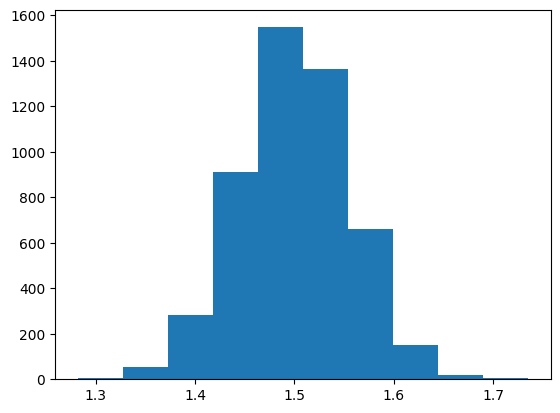

np.float64(0.0038)

In [22]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn import linear_model
rng = default_rng(32)
beta_0 = 7
beta_1 = 1.5

# get three 'values' of x at each integer from 0 to 10.
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)
n = len(x)

#prepare for the LR fit
reg = linear_model.LinearRegression()

#Create a reg object
#initialize array to save estimates (we don't need beta0 but I'm keeping it!)
beta_array = np.zeros(shape = (5000, 2))

for i in range(5000):
    #create the 'responses' modeled from the line plus a random deviation
    y = beta_0 + beta_1*x + rng.standard_normal(n)
    #find the least squares solutions and store them
    fit = reg.fit(x.reshape(-1, 1), y)
    beta_array[i, :] = [fit.intercept_, fit.coef_[0]]

#visualize the distribution of the slopedata
plt.hist(beta_array[:, 1])
plt.show()

#estimate the probability we are larger than 1.65
bool_prob = beta_array[:, 1] > 1.65
bool_prob.mean()

Instead of writing this simulation in this way, we’ll design a Python class that encapsulates the simulation
of the sampling distribution of the slope estimator!

Create a class called `SLR_slope_simulator`:

- Initialize the class using `__init__` with arguments `self`, `beta_0`, `beta_1`, `x`, `sigma`, and `seed`

    - Create initial attributes of `beta_0`, `beta_1`, `sigma`, `x`, `n`, `rng`, and `slopes` (an empty list)

- Required Methods. Your class should include methods (not `@classmethod`, just methods that work on an already created instances of the class):

    -  `generate_data` method that generates one dataset (returning x and y in whatever manner you deem fit, i.e. as an array, two arrays, etc.)

    - `fit_slope` method that takes in an `x` and `y` and fits the SLR model, returning the estimated slope

    - `run_simulations` method that takes in a number of simulations argument and uses the `generate_data()` and `fit_slope()` methods within a for loop. This should not return anything but should modify the `slopes` attribute (replaces it with an array of slope estimates)

    - `plot_sampling_distribution` method that checks if the `slopes` attribute has length greater than 0 (if it doesn’t print a message that `run_simulations()` must be called first). If it is, it should produce a histogram of the slopes approximating the sampling distribution.

    - `find_prob` method that takes in a `value` and a `sided` argument. It should checks on the `slopes` attribute as above. If the length is bigger than 0, it should approximate the probability of being “above”, “below”, or “two-sided” (values for `sided`).

        - If `sided` is “above”, you should approximate the probability of being larger than the value.
        - If it is “below”, you should approximate the probability of being smaller than the value.
        - If it is “two-sided”, you should approximate the probability of being larger in absolute value

- Below you definition of your class and its methods, add a section of code that
    - Creates an instance of the object with `beta_0 = 12, beta_1 = 2, x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3), sigma = 1`, and `seed = 10`
    - Call your `run_simulation()` method (this should return the error message)
    - Run 10000 simulations
    - Plot the sampling distribution
    - Approximate the two-sided probability of being larger than 2.1
    - Print out the value of the simulated slopes using the attribute


In [105]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn import linear_model

class SLR_slope_simulator:

    # Initialize the class
    def __init__(self, beta_0, beta_1, x, sigma, seed):
        self.beta_0 = beta_0
        self.beta_1 = beta_1
        self.sigma = sigma
        self.x = x
        self.n = len(x)
        self.rng = default_rng(seed)
        self.slopes = []

    # generate_data method
    def generate_data(self):
        y = self.beta_0 + self.beta_1 * self.x + self.rng.normal(0, self.sigma, self.n) # generate y
        return self.x, y

    # fit_slope method
    def fit_slope(self, x, y):
        reg = linear_model.LinearRegression()
        reg.fit(x.reshape(-1, 1), y) # fit LM
        return reg.coef_[0] # return the slope

    # plot_sampling_distribution method
    def run_simulations(self, simulate_times):
        slopes = []
        for _ in range(simulate_times):
            x, y = self.generate_data() # call generate_data method to get x and y
            slope = self.fit_slope(x, y) # call fit_slope method to get slope
            slopes.append(slope) # save slopes
        self.slopes = np.array(slopes)

    # plot_sampling_distribution method
    def plot_sampling_distribution(self):
        if len(self.slopes) == 0:
            print("Please run the run_simulations() method first.")
            return
        else:
            plt.hist(self.slopes)
            plt.title("Sampling Distribution of Slope")
            plt.xlabel("Slope estimate")
            plt.ylabel("Frequency")
            plt.show()

    # find_prob method
    def find_prob(self, value, sided = "two-sided"):
        if len(self.slopes) == 0:
            print("Please run the run_simulations() method first.")
            return
        else:
            if sided == "two-sided":
                prob = np.mean(np.abs(self.slopes) > np.abs(value))
            elif sided == "above":
                prob = np.mean(self.slopes > value)
            elif sided == "below":
                prob = np.mean(self.slopes < value)
            return prob



Try the class

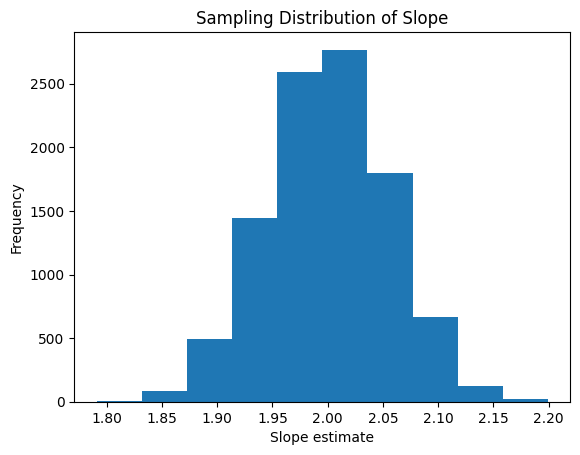

The two-sided probability is: 0.0352
[2.0239168  1.99560551 2.04249093 ... 1.93451109 2.01445559 2.07173587]


In [106]:
# Creates an instance of the object
ins = SLR_slope_simulator(
    beta_0 = 12,
    beta_1 = 2,
    x = np.array(list(np.linspace(start = 0, stop = 10, num = 11)) * 3),
    sigma = 1,
    seed = 10
)

# Run 10000 simulations
ins.run_simulations(10000)

# Plot the sampling distribution
ins.plot_sampling_distribution()

# Approximate the two-sided probability of being larger than 2.1
prob = ins.find_prob(2.1, sided = "two-sided")
print("The two-sided probability is:", prob)

# Print out the value of the simulated slopes using the attribute
print(ins.slopes)

# Submission

Now you can grab the ‘share’ link and submit that! Please make sure to change the sharing settings so that
anyone with the link can see the notebook. Good luck and let us know if you run into issues.